In [1]:
from matcher_wrapper import ELoFTRWrapper

model = ELoFTRWrapper(thr=0.1)


{'backbone_type': 'RepVGG', 'align_corner': False, 'resolution': (8, 1), 'fine_window_size': 8, 'mp': False, 'replace_nan': True, 'half': False, 'backbone': {'block_dims': [64, 128, 256]}, 'coarse': {'d_model': 256, 'd_ffn': 256, 'nhead': 8, 'layer_names': ['self', 'cross', 'self', 'cross', 'self', 'cross', 'self', 'cross'], 'agg_size0': 4, 'agg_size1': 4, 'no_flash': False, 'rope': True, 'npe': [832, 832, 832, 832]}, 'match_coarse': {'thr': 0.2, 'border_rm': 2, 'dsmax_temperature': 0.1, 'skip_softmax': False, 'fp16matmul': False, 'train_coarse_percent': 0.2, 'train_pad_num_gt_min': 200}, 'match_fine': {'local_regress_temperature': 10.0, 'local_regress_slicedim': 8}}


In [2]:
im1_path = "assets/toronto_A.jpg"
im2_path = "assets/toronto_B.jpg"

import cv2

import kornia as K

def load_image(image_path):
            
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image


image0 = load_image(im1_path)
image1 = load_image(im2_path)

import torch
with torch.inference_mode():
    out = model(image0, image1)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm

def make_matching_figure(
        img0, img1, mkpts0, mkpts1, color,
        kpts0=None, kpts1=None, text=[], dpi=75, path=None):
    # draw image pair
    assert mkpts0.shape[0] == mkpts1.shape[0], f'mkpts0: {mkpts0.shape[0]} v.s. mkpts1: {mkpts1.shape[0]}'
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=dpi)
    axes[0].imshow(img0, cmap='gray')
    axes[1].imshow(img1, cmap='gray')
    for i in range(2):   # clear all frames
        axes[i].get_yaxis().set_ticks([])
        axes[i].get_xaxis().set_ticks([])
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    plt.tight_layout(pad=1)
    
    if kpts0 is not None:
        assert kpts1 is not None
        axes[0].scatter(kpts0[:, 0], kpts0[:, 1], c='w', s=2)
        axes[1].scatter(kpts1[:, 0], kpts1[:, 1], c='w', s=2)

    # draw matches
    if mkpts0.shape[0] != 0 and mkpts1.shape[0] != 0:
        fig.canvas.draw()
        transFigure = fig.transFigure.inverted()
        fkpts0 = transFigure.transform(axes[0].transData.transform(mkpts0))
        fkpts1 = transFigure.transform(axes[1].transData.transform(mkpts1))
        fig.lines = [matplotlib.lines.Line2D((fkpts0[i, 0], fkpts1[i, 0]),
                                            (fkpts0[i, 1], fkpts1[i, 1]),
                                            transform=fig.transFigure, c=color[i], linewidth=1)
                                        for i in range(len(mkpts0))]
        
        axes[0].scatter(mkpts0[:, 0], mkpts0[:, 1], c=color, s=4)
        axes[1].scatter(mkpts1[:, 0], mkpts1[:, 1], c=color, s=4)

    # put txts
    txt_color = 'k' if img0[:100, :200].mean() > 200 else 'w'
    fig.text(
        0.01, 0.99, '\n'.join(text), transform=fig.axes[0].transAxes,
        fontsize=15, va='top', ha='left', color=txt_color)

    # save or return figure
    if path:
        plt.savefig(str(path), bbox_inches='tight', pad_inches=0)
        plt.close()
    
    return fig

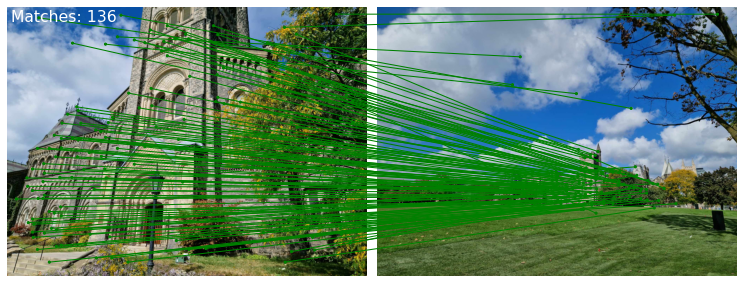

In [4]:
import cv2
source_image = cv2.imread(im1_path)
target_image = cv2.imread(im2_path)
source_rgb = cv2.cvtColor(source_image, cv2.COLOR_BGR2RGB)  # Convert to RGB
target_rgb = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)  # Convert to RGB

mconf2 = out["confidence"].cpu().numpy()
mkpts02 = out["keypoints0"].cpu().numpy()
mkpts12 = out["keypoints1"].cpu().numpy()

color = ['g']*len(mconf2)
text = [
    # 'Ours',
    'Matches: {}'.format(len(mkpts02)),
]

fig = make_matching_figure(source_rgb, target_rgb, mkpts02, mkpts12, color, text=text)

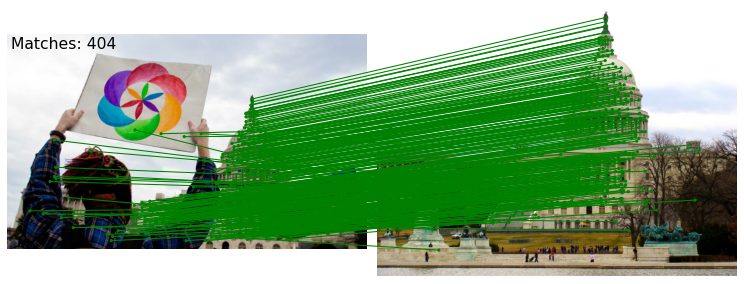

In [5]:
im1_path = "assets/phototourism_sample_images/united_states_capitol_26757027_6717084061.jpg"
im2_path = "assets/phototourism_sample_images/united_states_capitol_98169888_3347710852.jpg"


def demo_pair(im1_path, im2_path):
    source_image = cv2.imread(im1_path)
    target_image = cv2.imread(im2_path)
    source_rgb = cv2.cvtColor(source_image, cv2.COLOR_BGR2RGB)  # Convert to RGB
    target_rgb = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)  # Convert to RGB

    with torch.inference_mode():
        out = model(source_rgb, target_rgb)


    mconf2 = out["confidence"].cpu().numpy()
    mkpts02 = out["keypoints0"].cpu().numpy()
    mkpts12 = out["keypoints1"].cpu().numpy()

    color = ['g']*len(mconf2)
    text = [
        # 'Ours',
        'Matches: {}'.format(len(mkpts02)),
    ]

    fig = make_matching_figure(source_rgb, target_rgb, mkpts02, mkpts12, color, text=text)

demo_pair(im1_path, im2_path)